<a href="https://colab.research.google.com/github/AdnanTIF-0064/praktikum-struktur-data-SMT-2/blob/main/pertemuan_10_dijkstra_s2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STRUKTUR DATA GRAF DAN ALGORITMA

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    previous = {node: None for node in graph}

    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

MEREKONTRUKSI JALUR

In [ ]:
def get_path(previous, target):
    path = []

    while target is not None:
        path.insert(0, target)
        target = previous[target]

    return path

VISUALISASI DENGAN NETWORK DAN MATPLOTLIP

In [ ]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_weight='bold',
        arrows=True
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color='red',
            width=3
        )

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

PENGGUNAAN LENGKAP

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


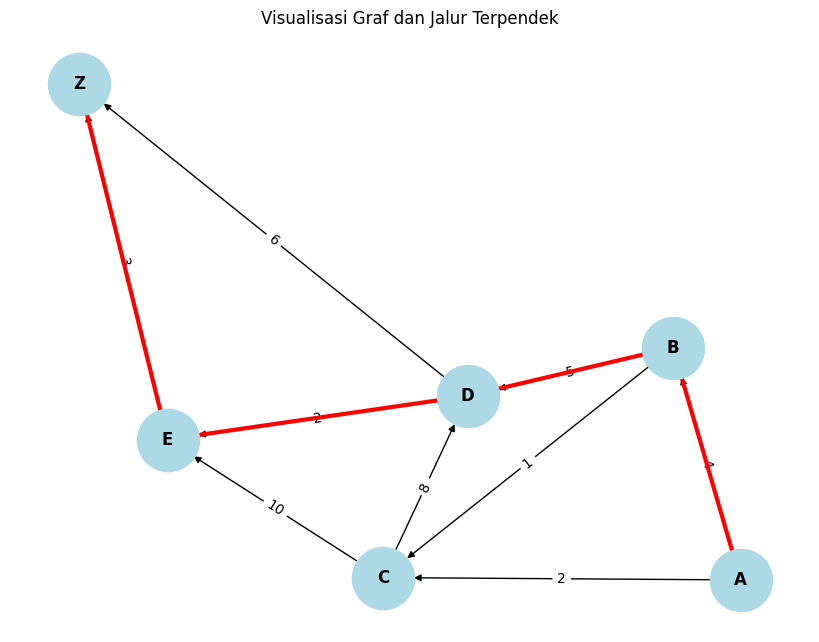

In [ ]:
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

TUGAS

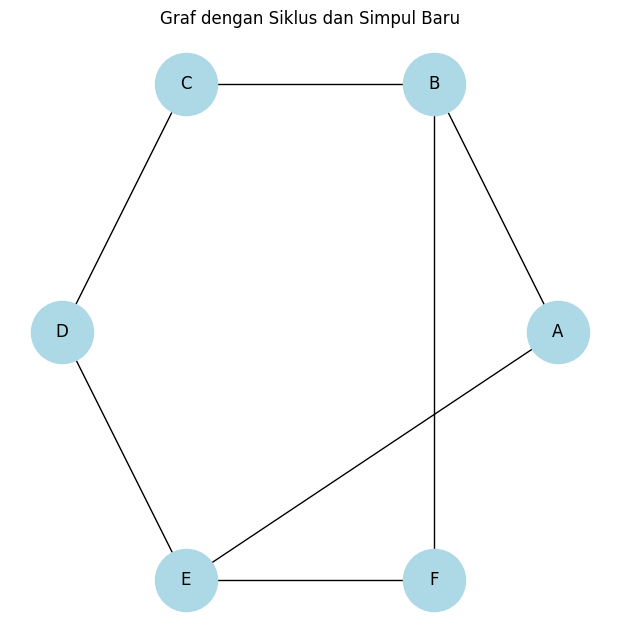

Jalur terpendek A ke D: ['A', 'E', 'D']
Panjang jalur: 2


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Membuat graf awal
G = nx.Graph()

# Menambahkan sisi
G.add_edges_from([
    ('A', 'B'),
    ('B', 'C'),
    ('C', 'D'),
    ('D', 'E')
])

# ==========================
# 1. Menambahkan siklus
# ==========================
G.add_edge('E', 'A')  # Membentuk siklus A-B-C-D-E-A

# ==========================
# 2. Menambahkan simpul baru
# ==========================
G.add_node('F')
G.add_edges_from([
    ('F', 'B'),
    ('F', 'E')
])

# Visualisasi dengan Circular Layout
plt.figure(figsize=(6,6))
pos = nx.circular_layout(G)
nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_size=12)
plt.title("Graf dengan Siklus dan Simpul Baru")
plt.show()

# ==========================
# Jalur terpendek sebelum dan sesudah
# ==========================
shortest_path = nx.shortest_path(G, source='A', target='D')
print("Jalur terpendek A ke D:", shortest_path)
print("Panjang jalur:", len(shortest_path)-1)